# Lab 8: Vanilla Scikit-Learn Baseline for NEO Classification

**Project idea:** compare a simple machine-learning classifier against the existing VDP Bayesian velocity-density classifier and digest2 for identifying Near-Earth Objects (NEOs) from synthetic moving-object observations.

This notebook is the Lab 8 planning/baseline notebook. It focuses on:

1. understanding the data,
2. understanding the classification task, and
3. making an initial model/evaluation plan.

The setup used here: split the S3M subset in half, train on one half, and test on the other half.

## 1. Setup

We use scikit-learn models first because they are fast, interpretable baselines. A neural network should beat or at least meaningfully compare against these simple models before we spend effort on a CNN.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)

DATA_PATH = Path("..") / "s3m_digest2_comparison.parquet"
TEST_SIZE = 0.50

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
print("data path:", DATA_PATH.resolve())

data path: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/s3m_digest2_comparison.parquet


## 2. Understanding the Data

The dataset is a corrected synthetic S3M comparison sample. Each row is one visible object in the VDP/digest2 comparison region. The populations are:

- `NEO`: Near-Earth Object, the positive class
- `MBA`: main-belt asteroid, negative class
- `TNO`: trans-Neptunian object, negative class
- `Trojans`: Jupiter Trojans, negative class

The parquet also contains VDP and digest2 scores, but those are **not** training inputs. They are benchmark scores for comparison after training.

In [2]:
df_raw = pd.read_parquet(DATA_PATH)
print(f"Raw rows: {len(df_raw):,}")
print("Columns:")
print(list(df_raw.columns))
print("\nPopulation counts:")
print(df_raw["true_population"].value_counts().to_string())

display(df_raw.head())

Raw rows: 38,045
Columns:
['true_population', 'lam_deg', 'vlam', 'vbeta', 'mag_app', 'H', 'P_NEO_vdp', 'P_NEO_d2']

Population counts:
true_population
MBA        15350
Trojans    13035
TNO         7427
NEO         2233


,true_population,lam_deg,vlam,vbeta,mag_app,H,P_NEO_vdp,P_NEO_d2
0,NEO,188.213266,-0.224582,0.020553,18.110710,11.452,0.000172,0.41
1,NEO,169.925547,-0.346591,0.053089,16.340715,12.430,0.519185,0.96
2,NEO,190.416689,-0.385974,-0.013405,17.992193,13.901,0.847608,1.00
3,NEO,163.777123,-0.258691,0.032913,18.760917,14.092,0.000304,0.60
4,NEO,175.908696,-0.274626,-0.008760,20.302876,15.092,0.004728,0.15


### Data Size and Class Balance

The task is imbalanced because NEOs are rare compared with non-NEOs. This means plain accuracy can be misleading: a classifier can get high accuracy by predicting every object is non-NEO.

Total objects: 38,045
NEO fraction: 5.87%
All-non-NEO accuracy baseline: 94.13%


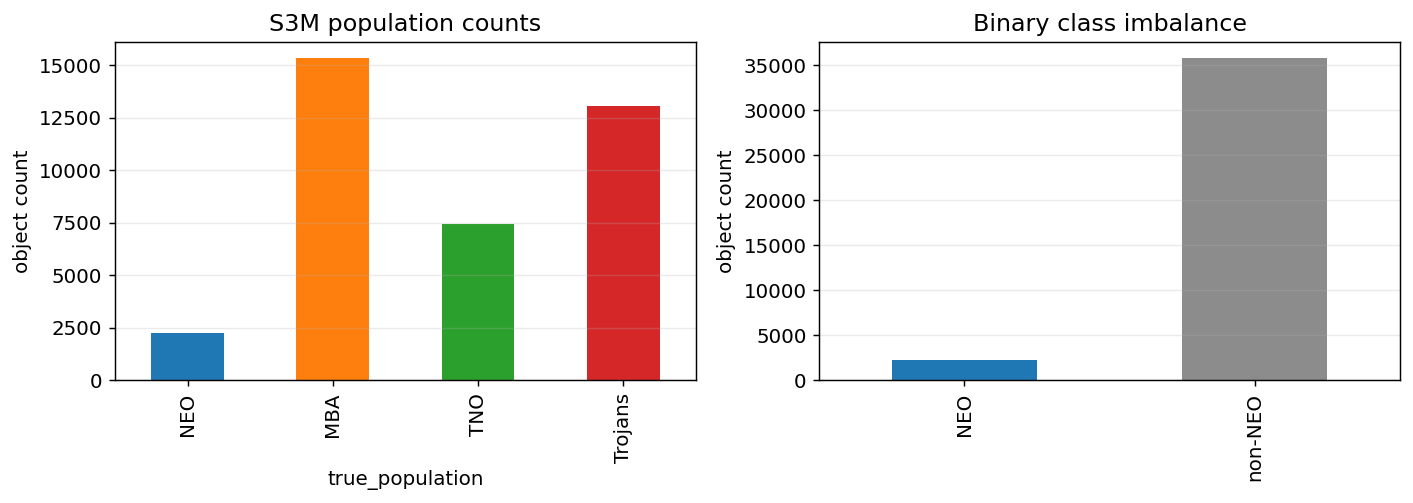

In [3]:
pop_counts = df_raw["true_population"].value_counts().reindex(["NEO", "MBA", "TNO", "Trojans"])
neo_fraction = (df_raw["true_population"] == "NEO").mean()
print(f"Total objects: {len(df_raw):,}")
print(f"NEO fraction: {neo_fraction:.2%}")
print(f"All-non-NEO accuracy baseline: {1 - neo_fraction:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pop_counts.plot(kind="bar", ax=axes[0], color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
axes[0].set_ylabel("object count")
axes[0].set_title("S3M population counts")
axes[0].grid(axis="y", alpha=0.25)

binary_counts = pd.Series({"NEO": pop_counts["NEO"], "non-NEO": len(df_raw) - pop_counts["NEO"]})
binary_counts.plot(kind="bar", ax=axes[1], color=["tab:blue", "0.55"])
axes[1].set_ylabel("object count")
axes[1].set_title("Binary class imbalance")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Data Cleanness Check

For this first baseline, the needed observable columns are checked for missing or non-finite values.

In [4]:
observable_cols = ["vlam", "vbeta", "mag_app", "lam_deg"]
benchmark_cols = ["P_NEO_vdp", "P_NEO_d2"]
needed_cols = ["true_population"] + observable_cols + benchmark_cols

missing_cols = [c for c in needed_cols if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

clean_mask = np.ones(len(df_raw), dtype=bool)
for col in needed_cols:
    if col == "true_population":
        clean_mask &= df_raw[col].notna().to_numpy()
    else:
        clean_mask &= np.isfinite(df_raw[col].to_numpy(float))

df = df_raw.loc[clean_mask].copy().reset_index(drop=True)
print(f"Rows after finite-value cleaning: {len(df):,}")
print(f"Dropped rows: {len(df_raw) - len(df):,}")

display(df[observable_cols + benchmark_cols].describe().T)

Rows after finite-value cleaning: 38,045
Dropped rows: 0


,count,mean,std,min,25%,50%,75%,max
vlam,38045.0,-0.153485,0.102156,-0.798882,-0.211748,-0.134455,-0.109885,0.609668
vbeta,38045.0,0.000749,0.062880,-0.790087,-0.014004,0.000145,0.017238,0.769277
mag_app,38045.0,23.876031,1.342029,15.014110,23.173759,24.135567,24.786405,25.999908
lam_deg,38045.0,174.044743,16.547100,150.016269,159.762295,170.594487,187.100196,209.993254
P_NEO_vdp,38045.0,0.033086,0.169577,0.000000,0.000023,0.000128,0.000371,0.998661
P_NEO_d2,38045.0,0.205272,0.308111,0.000000,0.010000,0.030000,0.290000,1.000000


### Obvious Patterns

The most important observable feature is expected to be sky-plane motion. VDP is also based on the fact that different solar-system populations occupy different regions in ecliptic velocity space.

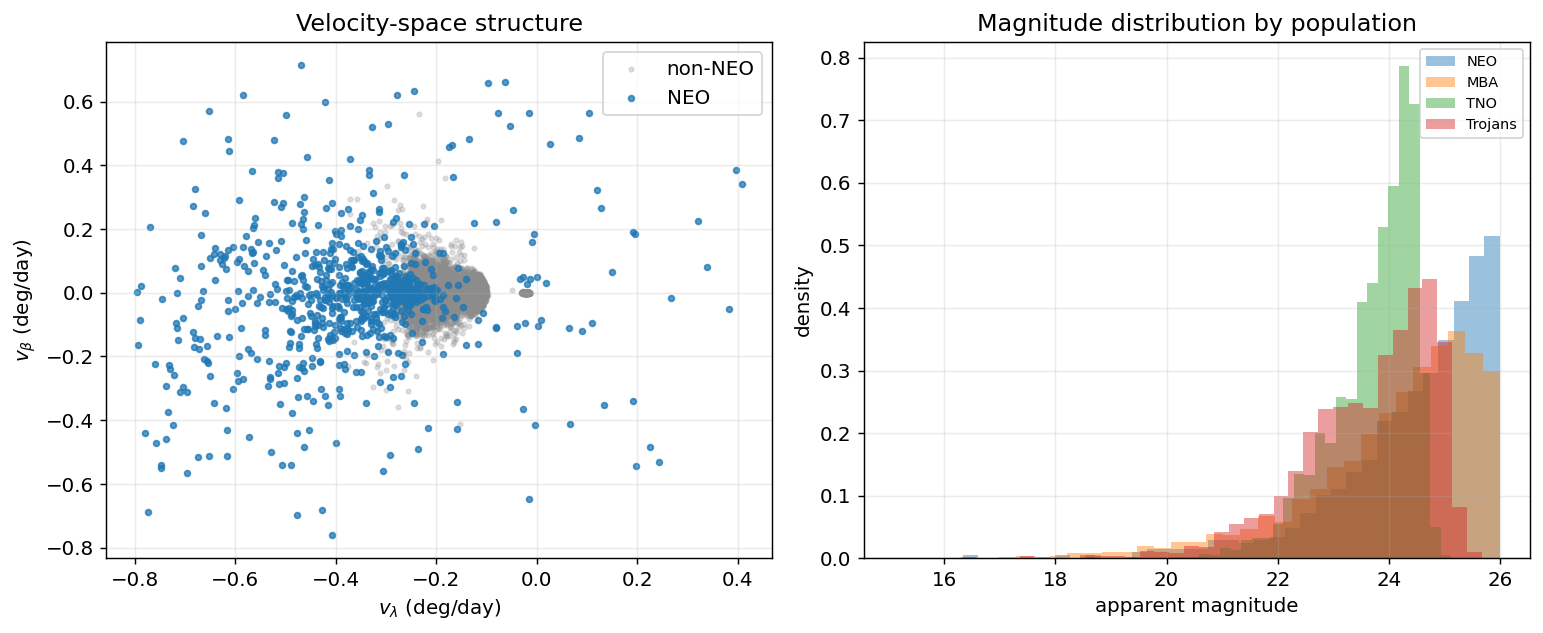

In [5]:
plot_df = df.sample(min(len(df), 12000), random_state=RANDOM_SEED).copy()
plot_df["label"] = np.where(plot_df["true_population"] == "NEO", "NEO", "non-NEO")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, color, alpha, size in [("non-NEO", "0.55", 0.25, 6), ("NEO", "tab:blue", 0.75, 10)]:
    sub = plot_df[plot_df["label"] == label]
    axes[0].scatter(sub["vlam"], sub["vbeta"], s=size, alpha=alpha, label=label, color=color, rasterized=True)
axes[0].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[0].set_ylabel(r"$v_\beta$ (deg/day)")
axes[0].set_title("Velocity-space structure")
axes[0].legend()
axes[0].grid(alpha=0.25)

for pop, color in [("NEO", "tab:blue"), ("MBA", "tab:orange"), ("TNO", "tab:green"), ("Trojans", "tab:red")]:
    sub = plot_df[plot_df["true_population"] == pop]
    axes[1].hist(sub["mag_app"], bins=35, alpha=0.45, density=True, label=pop, color=color)
axes[1].set_xlabel("apparent magnitude")
axes[1].set_ylabel("density")
axes[1].set_title("Magnitude distribution by population")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Understanding the Task

This is a **binary classification** problem:

```text
input  = observable tracklet-level features
output = probability or score that the object is a NEO
```

The positive class is:

```text
true_population == "NEO"
```

The significance is that NEO candidates are follow-up limited. A useful classifier should recover many real NEOs while keeping contamination low.

Because the dataset is imbalanced, the main evaluation metrics are:

- **completeness:** fraction of true NEOs recovered
- **contamination:** fraction of selected candidates that are not NEOs
- **purity:** `1 - contamination`
- **F1:** harmonic mean of completeness and purity
- **ROC-AUC / average precision:** threshold-independent ranking metrics

A good first performance goal is to be competitive with the existing benchmark methods on the same held-out test set.

## 4. Features and Labels

Training inputs are deliberately restricted to observable-style features. The model is **not** allowed to train on VDP/digest2 scores or orbital truth columns.

Base observable columns:

```text
vlam, vbeta, mag_app, lam_deg
```

Engineered observable features:

```text
sin(lam_deg), cos(lam_deg), sky_speed
```

Not used as training inputs:

```text
P_NEO_vdp, P_NEO_d2
P_MBA, P_NEO, P_TNO, P_Trojans
orbital elements such as a, e, i, q, MOID
H
```

In [6]:
def make_feature_table(frame):
    out = pd.DataFrame(index=frame.index)
    out["vlam"] = frame["vlam"].astype(float)
    out["vbeta"] = frame["vbeta"].astype(float)
    out["mag_app"] = frame["mag_app"].astype(float)
    out["lam_sin"] = np.sin(np.deg2rad(frame["lam_deg"].astype(float)))
    out["lam_cos"] = np.cos(np.deg2rad(frame["lam_deg"].astype(float)))
    out["sky_speed"] = np.hypot(out["vlam"], out["vbeta"])
    return out

X = make_feature_table(df)
y = (df["true_population"] == "NEO").astype(int).to_numpy()

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Features:", list(X.columns))
display(X.head())

Feature matrix shape: (38045, 6)
Label vector shape: (38045,)
Features: ['vlam', 'vbeta', 'mag_app', 'lam_sin', 'lam_cos', 'sky_speed']


,vlam,vbeta,mag_app,lam_sin,lam_cos,sky_speed
0,-0.224582,0.020553,18.110710,-0.142858,-0.989743,0.225520
1,-0.346591,0.053089,16.340715,0.174928,-0.984581,0.350633
2,-0.385974,-0.013405,17.992193,-0.180806,-0.983519,0.386207
3,-0.258691,0.032913,18.760917,0.279375,-0.960182,0.260777
4,-0.274626,-0.008760,20.302876,0.071346,-0.997452,0.274765


## 5. 50/50 Stratified Train-Test Split

The S3M subset is split in half. The split is stratified so the rare NEO class has nearly the same fraction in train and test.

In [7]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

for name, yy in [("train", y_train), ("test", y_test)]:
    print(f"{name:5s}: n={len(yy):6,d}, NEOs={yy.sum():5,d}, NEO fraction={yy.mean():.2%}")

train: n=19,022, NEOs=1,116, NEO fraction=5.87%
test : n=19,023, NEOs=1,117, NEO fraction=5.87%


## 6. Vanilla Scikit-Learn Models

Three simple baselines are trained:

1. `DummyClassifier`: sanity-check baseline.
2. `LogisticRegression`: classical linear model with balanced class weights.
3. `RandomForestClassifier`: nonlinear classical model with balanced class weights.
4. `MLPClassifier`: a vanilla fully connected scikit-learn neural network.

The MLP does not use class weights in this scikit-learn version, so the threshold scan is especially important.

In [8]:
models = {
    "Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_SEED),
    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_SEED,
        )),
    ]),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Scikit MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 32),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            n_iter_no_change=25,
            random_state=RANDOM_SEED,
        )),
    ]),
}

fitted_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
print("Done.")

Training Dummy...
Training Logistic regression...
Training Random forest...
Training Scikit MLP...
Done.


## 7. Evaluation Functions

The same threshold-scanning logic is used for all models and benchmarks. A classifier score becomes a selected NEO candidate if:

```text
score >= threshold
```

In [9]:
def get_positive_score(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_values)
        return 1.0 / (1.0 + np.exp(-raw))
    raise TypeError("Model has neither predict_proba nor decision_function.")


def metric_at_threshold(scores, y_true, threshold):
    scores = np.asarray(scores, dtype=float)
    y_true = np.asarray(y_true, dtype=bool)
    selected = scores >= threshold
    tp = np.sum(selected & y_true)
    fp = np.sum(selected & ~y_true)
    n_neo = np.sum(y_true)
    completeness = tp / max(n_neo, 1)
    contamination = fp / max(tp + fp, 1)
    purity = 1.0 - contamination
    f1 = 0.0 if purity + completeness == 0 else 2.0 * purity * completeness / (purity + completeness)
    return completeness, contamination, purity, f1, tp, fp, selected.sum()


def curve_and_best(scores, y_true, thresholds=np.linspace(0.0, 1.0, 401)):
    rows = []
    for threshold in thresholds:
        comp, cont, purity, f1, tp, fp, selected = metric_at_threshold(scores, y_true, threshold)
        rows.append((threshold, comp, cont, purity, f1, tp, fp, selected))
    curve = pd.DataFrame(
        rows,
        columns=["threshold", "completeness", "contamination", "purity", "F1", "TP", "FP", "selected"],
    )
    best = curve.iloc[curve["F1"].idxmax()]
    return curve, best

## 8. Held-Out Test Results

The model is evaluated only on the held-out test half. VDP and digest2 are evaluated on the same test rows for a direct comparison.

In [10]:
scores = {}

for name, model in fitted_models.items():
    scores[name] = get_positive_score(model, X_test)

# Benchmark scores. These are not training features.
scores["VDP"] = test_df["P_NEO_vdp"].to_numpy(float)
scores["digest2"] = test_df["P_NEO_d2"].to_numpy(float)

curves = {}
summary_rows = []
for name, score in scores.items():
    curve, best = curve_and_best(score, y_test)
    curves[name] = curve
    try:
        auc = roc_auc_score(y_test, score)
    except ValueError:
        auc = np.nan
    try:
        ap = average_precision_score(y_test, score)
    except ValueError:
        ap = np.nan
    acc_05 = np.mean((score >= 0.5) == y_test)
    summary_rows.append({
        "classifier": name,
        "accuracy@0.5": acc_05,
        "ROC-AUC": auc,
        "avg_precision": ap,
        "best_threshold": best["threshold"],
        "completeness": best["completeness"],
        "contamination": best["contamination"],
        "purity": best["purity"],
        "F1": best["F1"],
        "selected": int(best["selected"]),
        "TP": int(best["TP"]),
        "FP": int(best["FP"]),
    })

summary = pd.DataFrame(summary_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(summary.style.format({
    "accuracy@0.5": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "avg_precision": "{:.3f}",
    "best_threshold": "{:.3f}",
    "completeness": "{:.1%}",
    "contamination": "{:.1%}",
    "purity": "{:.1%}",
    "F1": "{:.3f}",
}))

,classifier,accuracy@0.5,ROC-AUC,avg_precision,best_threshold,completeness,contamination,purity,F1,selected,TP,FP
0,Scikit MLP,0.987,0.983,0.931,0.390,84.3%,6.7%,93.3%,0.886,1010,942,68
1,Random forest,0.982,0.987,0.933,0.735,83.7%,9.2%,90.8%,0.871,1030,935,95
2,VDP,0.975,0.975,0.899,0.005,79.2%,5.3%,94.7%,0.863,935,885,50
3,Logistic regression,0.952,0.974,0.854,0.710,86.5%,21.9%,78.1%,0.821,1237,966,271
4,digest2,0.822,0.847,0.644,0.973,52.5%,5.6%,94.4%,0.674,621,586,35
5,Dummy,0.941,0.500,0.059,0.000,100.0%,94.1%,5.9%,0.111,19023,1117,17906


## 9. Plots: Completeness vs Contamination

The ideal region is lower right: high completeness and low contamination.

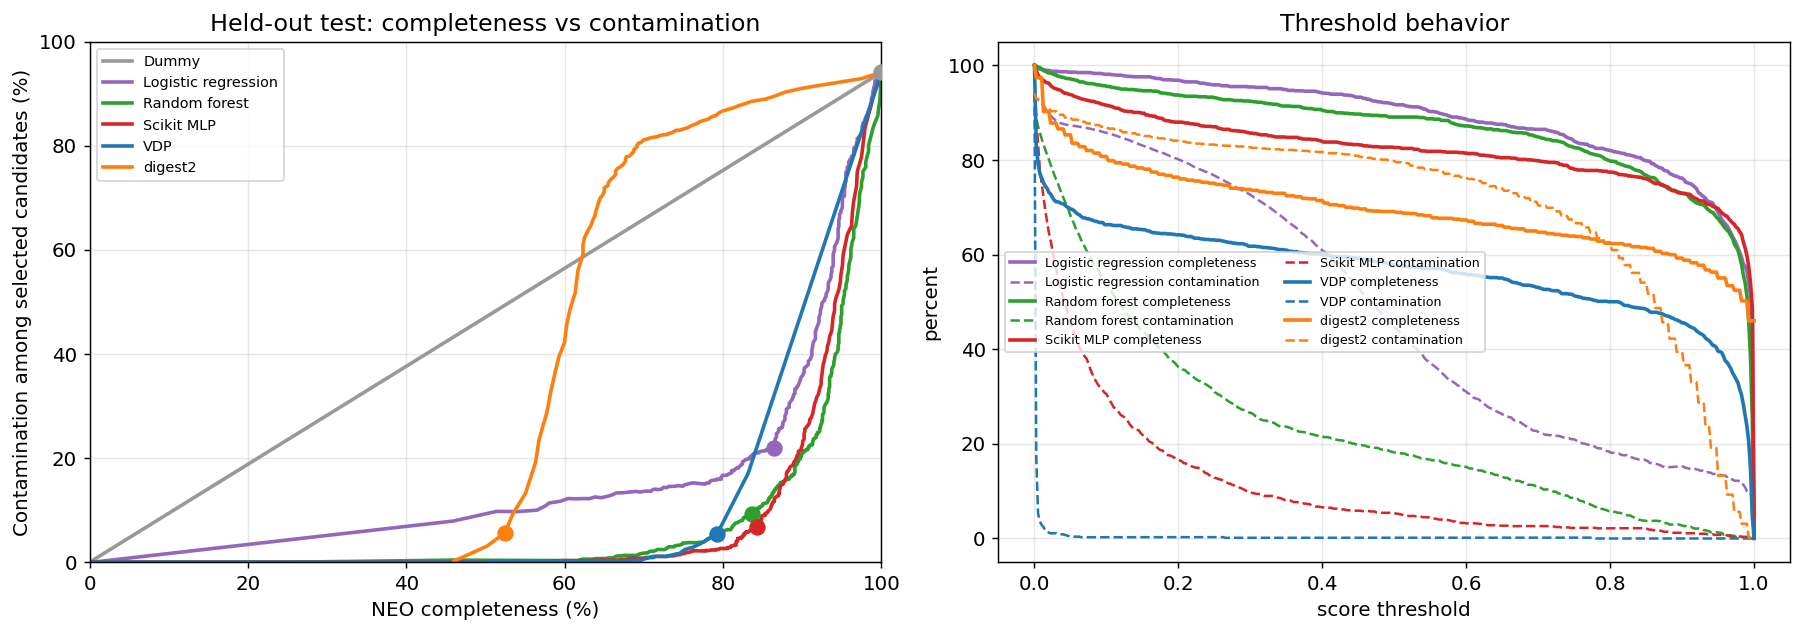

In [11]:
colors = {
    "Dummy": "0.6",
    "Logistic regression": "tab:purple",
    "Random forest": "tab:green",
    "Scikit MLP": "tab:red",
    "VDP": "tab:blue",
    "digest2": "tab:orange",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, curve in curves.items():
    ax.plot(curve["completeness"] * 100, curve["contamination"] * 100,
            lw=2.0, label=name, color=colors.get(name))
    best = curve.iloc[curve["F1"].idxmax()]
    ax.scatter(best["completeness"] * 100, best["contamination"] * 100,
               s=65, color=colors.get(name), zorder=5)
ax.set_xlabel("NEO completeness (%)")
ax.set_ylabel("Contamination among selected candidates (%)")
ax.set_title("Held-out test: completeness vs contamination")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for name, curve in curves.items():
    if name == "Dummy":
        continue
    ax.plot(curve["threshold"], curve["completeness"] * 100,
            lw=2, color=colors.get(name), label=f"{name} completeness")
    ax.plot(curve["threshold"], curve["contamination"] * 100,
            lw=1.4, color=colors.get(name), linestyle="--", label=f"{name} contamination")
ax.set_xlabel("score threshold")
ax.set_ylabel("percent")
ax.set_title("Threshold behavior")
ax.grid(alpha=0.3)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 10. Score Distributions

A useful classifier should push true NEOs toward high scores and non-NEOs toward low scores.

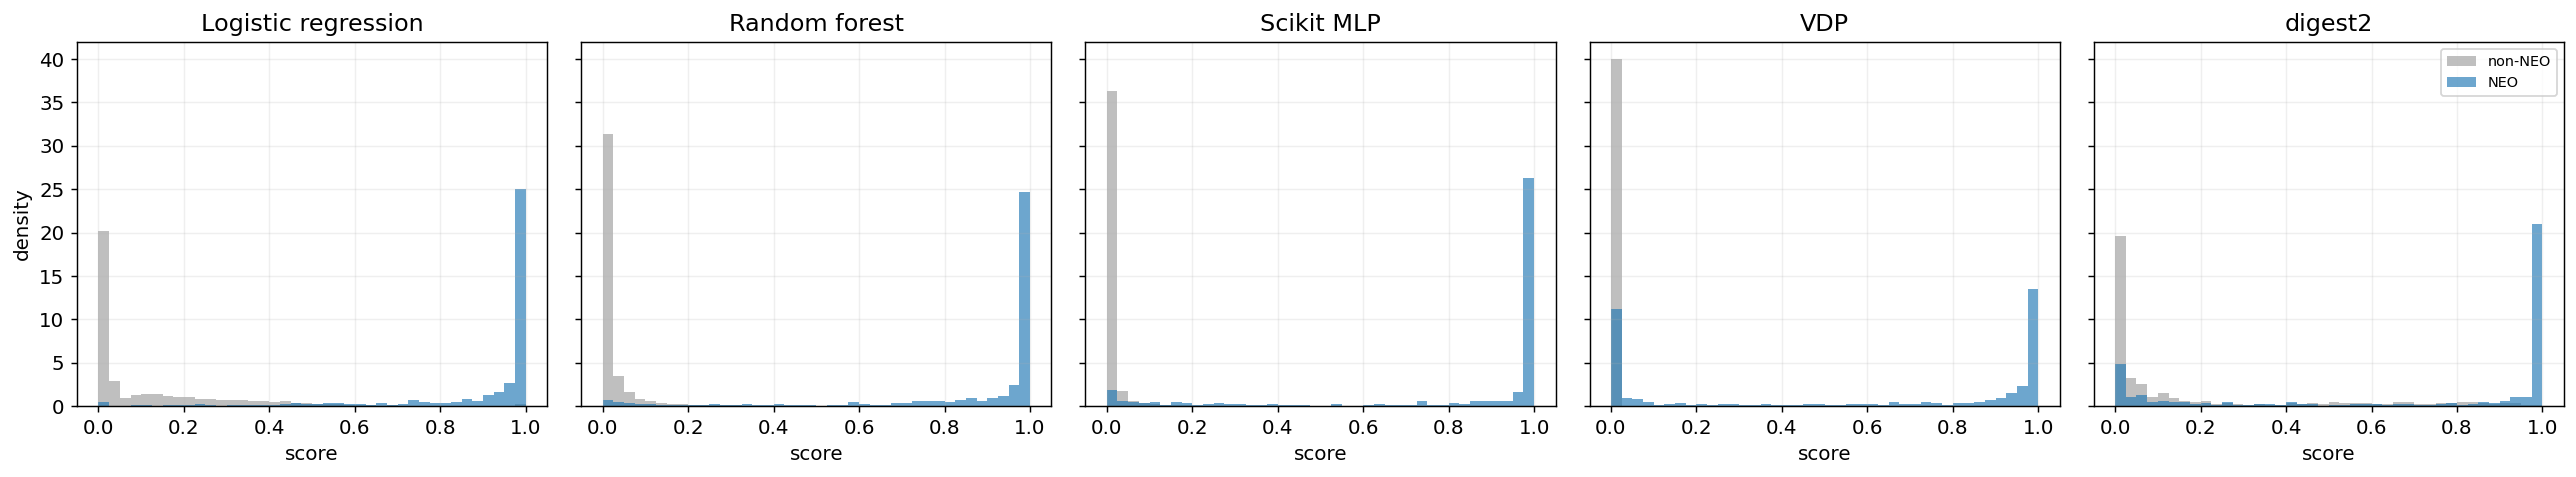

In [12]:
score_frame = test_df[["true_population"]].copy()
for name, score in scores.items():
    score_frame[name] = score

plot_names = ["Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]
fig, axes = plt.subplots(1, len(plot_names), figsize=(4 * len(plot_names), 3.8), sharey=True)

for ax, name in zip(axes, plot_names):
    ax.hist(score_frame.loc[score_frame["true_population"] != "NEO", name],
            bins=40, range=(0, 1), density=True, alpha=0.55, color="0.55", label="non-NEO")
    ax.hist(score_frame.loc[score_frame["true_population"] == "NEO", name],
            bins=40, range=(0, 1), density=True, alpha=0.65, color="tab:blue", label="NEO")
    ax.set_title(name)
    ax.set_xlabel("score")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("density")
axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Top-N Follow-Up Yield

This view is useful observationally: if only the top-ranked candidates can be followed up, how many true NEOs are recovered?

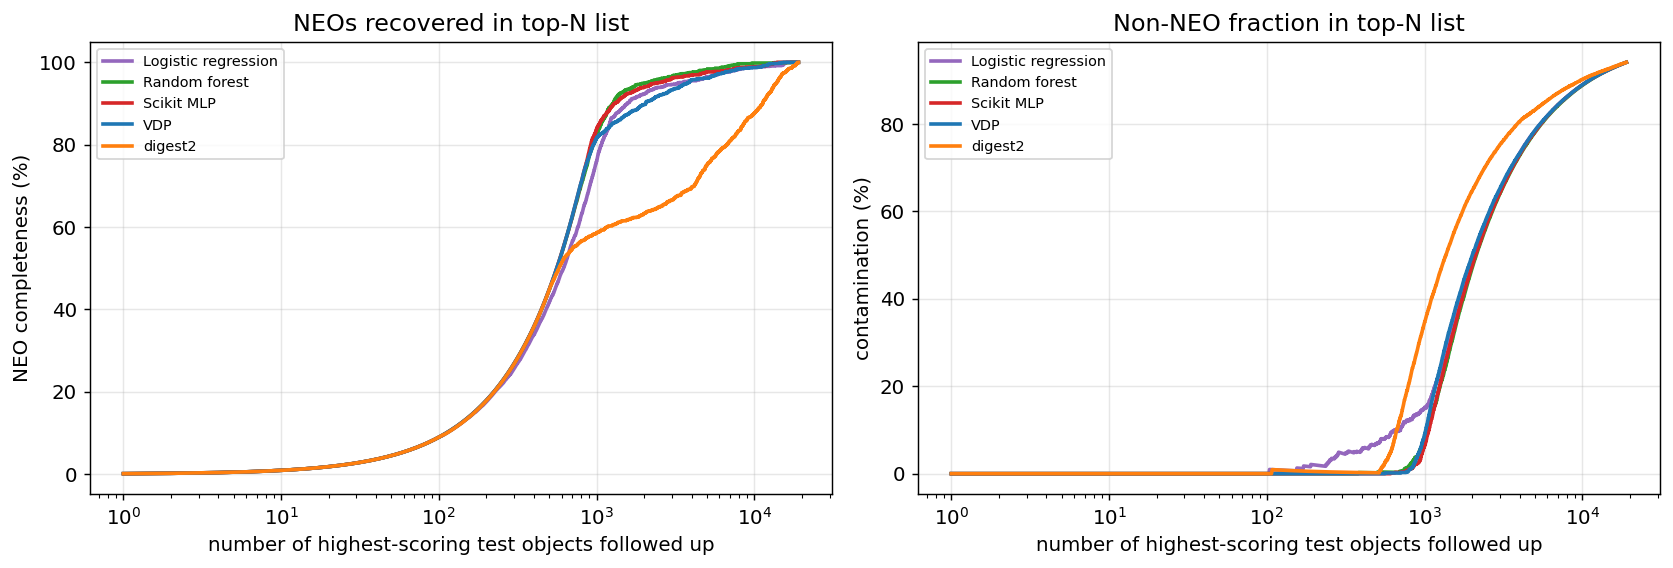

neo_recovered                                           \
classifier Logistic regression Random forest Scikit MLP     VDP digest2   
n_followed                                                                
25                        25.0          25.0       25.0    25.0    25.0   
50                        50.0          50.0       50.0    50.0    50.0   
100                      100.0         100.0      100.0   100.0   100.0   
250                      243.0         250.0      250.0   250.0   249.0   
500                      465.0         499.0      500.0   500.0   499.0   
1000                     849.0         920.0      936.0   911.0   653.0   
2500                    1049.0        1071.0     1062.0  1028.0   724.0   
5000                    1078.0        1097.0     1091.0  1074.0   838.0   

              completeness_pct                                          \
classifier Logistic regression Random forest Scikit MLP    VDP digest2   
n_followed                                                               
25                        2.24          2.24       2.24   2.24    2.24   
50                        4.48          4.48       4.48   4.48    4.48   
100                       8.95          8.95       8.95   8.95    8.95   
250                      21.75         22.38      22.38  22.38   22.29   
500                      41.63         44.67      44.76  44.76   44.67   
1000                     76.01         82.36      83.80  81.56   58.46   
2500                     93.91         95.88      95.08  92.03   64.82   
5000                     96.51         98.21      97.67  96.15   75.02   

             contamination_pct                                          
classifier Logistic regression Random forest Scikit MLP    VDP digest2  
n_followed                                                              
25                        0.00          0.00       0.00   0.00    0.00  
50                        0.00          0.00       0.00   0.00    0.00  
100                       0.00          0.00       0.00   0.00    0.00  
250                       2.80          0.00       0.00   0.00    0.40  
500                       7.00          0.20       0.00   0.00    0.20  
1000                     15.10          8.00       6.40   8.90   34.70  
2500                     58.04         57.16      57.52  58.88   71.04  
5000                     78.44         78.06      78.18  78.52   83.24

In [13]:
def followup_curve(frame, score, label):
    ordered = frame.assign(score=score).sort_values("score", ascending=False).reset_index(drop=True)
    selected = np.arange(1, len(ordered) + 1)
    neo_cum = (ordered["true_population"] == "NEO").cumsum().to_numpy()
    n_neo = (frame["true_population"] == "NEO").sum()
    return pd.DataFrame({
        "n_followed": selected,
        "neo_recovered": neo_cum,
        "completeness": neo_cum / max(n_neo, 1),
        "contamination": 1.0 - neo_cum / selected,
        "classifier": label,
    })

followup = pd.concat(
    [followup_curve(test_df, scores[name], name) for name in ["Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for name in ["Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]:
    sub = followup[followup["classifier"] == name]
    axes[0].plot(sub["n_followed"], sub["completeness"] * 100, lw=2, label=name, color=colors.get(name))
    axes[1].plot(sub["n_followed"], sub["contamination"] * 100, lw=2, label=name, color=colors.get(name))

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("number of highest-scoring test objects followed up")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("NEO completeness (%)")
axes[0].set_title("NEOs recovered in top-N list")
axes[1].set_ylabel("contamination (%)")
axes[1].set_title("Non-NEO fraction in top-N list")
plt.tight_layout()
plt.show()

summary_n = [25, 50, 100, 250, 500, 1000, 2500, 5000]
summary_n = [n for n in summary_n if n <= len(test_df)]
followup_summary = (
    followup[followup["n_followed"].isin(summary_n)]
    .assign(completeness_pct=lambda x: x["completeness"] * 100,
            contamination_pct=lambda x: x["contamination"] * 100)
    .pivot(index="n_followed", columns="classifier", values=["neo_recovered", "completeness_pct", "contamination_pct"])
)
display(followup_summary.round(2))

## 12. Lab 8 Checkout Answers

### Objective 1: Understanding the data

**Data size and structure.**  
The dataset has 38,045 synthetic visible S3M objects. Each row is one object in the corrected VDP/digest2 comparison sample. The available columns include object population label, ecliptic velocity components, apparent magnitude, ecliptic longitude, and benchmark scores from VDP and digest2.

**Data cleanness.**  
The first baseline checks for missing or non-finite values in the required observable and benchmark columns. Because the data are simulated, labels come from S3M population identity. A simulator limitation is that performance on S3M does not automatically prove performance on real survey candidates.

**Diversity and class balance.**  
The model uses a small number of tracklet-level features per object. The classes are highly imbalanced: NEOs are only about 6% of the sample, while MBAs, TNOs, and Trojans make up the non-NEO class.

### Objective 2: Understanding the task

**Problem type.**  
This is binary classification: NEO vs non-NEO.

**Significance.**  
NEO follow-up resources are limited. A better classifier should recover more true NEOs while keeping the candidate list clean.

**Evaluation metrics.**  
Accuracy is not enough because the data are imbalanced. The main metrics are completeness, contamination, purity, F1, ROC-AUC, average precision, and top-N follow-up yield.

**Good performance.**  
A useful model should perform better than a dummy classifier and be competitive with existing VDP/digest2 benchmarks on the held-out test set.

**Baseline methods.**  
This notebook uses scikit-learn baselines: logistic regression, random forest, and a vanilla MLP. VDP and digest2 are benchmark classifiers for comparison.

### Objective 3: Initial project plan

**Inputs and outputs.**  
Inputs are observable features such as `vlam`, `vbeta`, `mag_app`, and ecliptic longitude encodings. The output is a score or probability that the object is a NEO.

**Data preparation.**  
The data are cleaned for finite values, converted into a binary label, and split into 50% train and 50% test with stratification. Scaled models use `StandardScaler`.

**Model plan.**  
Start with vanilla scikit-learn models. If these are promising, then test a neural network model such as a fully connected network or CNN.

**Evaluation plan.**  
Evaluate on the held-out half only, then compare the scikit-learn scores against VDP and digest2 on the same test objects.